# 🔧 Data Cleaning & Feature Engineering — OctWave 3.0 Fraud Detection

**Objective:** Transform raw credit card transaction data into a clean, feature-rich dataset ready for model training.  
**Pipeline:** Load Raw Data → Validate & Clean → Feature Engineering → Encoding → Save Processed Data  
**Key Principle:** Every transformation is deliberate and justified by insights from our EDA (`01_EDA.ipynb`).

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palette
FRAUD_PALETTE = ['#2ecc71', '#e74c3c']
FEATURE_COLOR = '#3498db'
ACCENT_COLOR = '#e67e22'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Raw Data

We load both the training and test datasets from the raw data directory. The test set's `transaction_id` values are preserved separately for final submission formatting.

In [2]:
# Load raw datasets
train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print(f'Training set: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'Test set:     {test_df.shape[0]:,} rows × {test_df.shape[1]} columns')
print()
print('Training columns:', train_df.columns.tolist())
print('Test columns:    ', test_df.columns.tolist())

Training set: 8,000 rows × 10 columns
Test set:     2,000 rows × 9 columns

Training columns: ['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']
Test columns:     ['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


In [3]:
train_df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,6403,40.96,6,Food,0,1,82,2,51,0
1,5803,57.07,6,Electronics,0,0,42,2,18,0
2,4132,44.24,0,Grocery,0,0,26,2,25,0
3,7627,396.80,23,Clothing,0,0,97,1,34,0
4,6047,20.13,0,Food,0,0,91,1,28,0


## 3. Data Quality Validation

Before any transformation, we systematically verify data quality. This confirms our EDA findings and ensures no issues have been introduced during data collection.

### 3.1 Missing Values Check

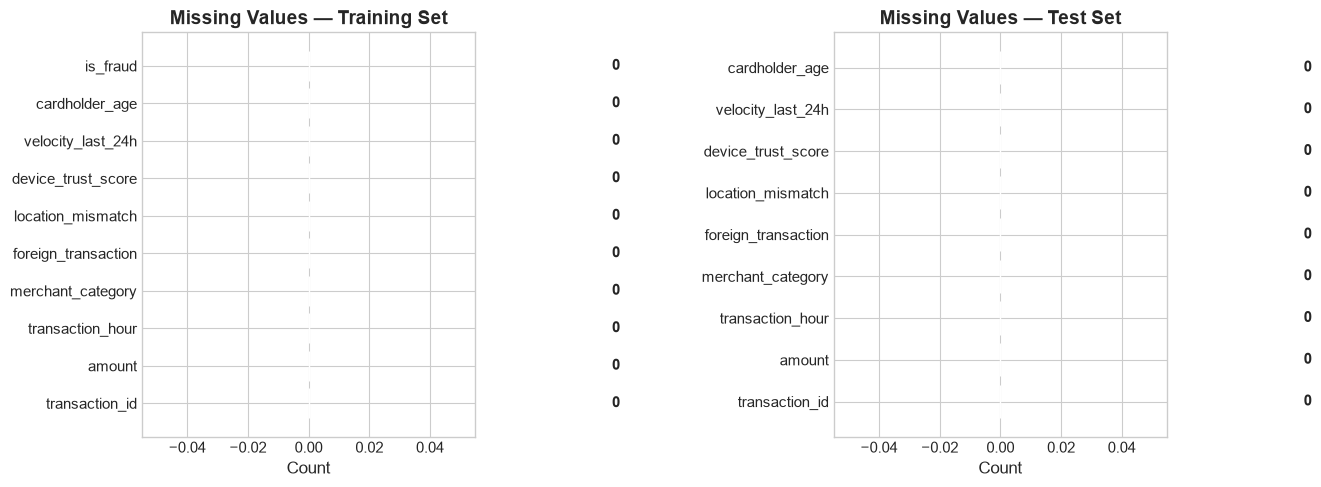

✅ No missing values in either dataset — no imputation needed.


In [4]:
# Check for missing values in both datasets
train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(train_missing.index, train_missing.values, color=FEATURE_COLOR, edgecolor='white')
axes[0].set_title('Missing Values — Training Set', fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(train_missing.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontweight='bold')

axes[1].barh(test_missing.index, test_missing.values, color=ACCENT_COLOR, edgecolor='white')
axes[1].set_title('Missing Values — Test Set', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(test_missing.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

assert train_df.isnull().sum().sum() == 0, 'Missing values found in train!'
assert test_df.isnull().sum().sum() == 0, 'Missing values found in test!'
print('✅ No missing values in either dataset — no imputation needed.')

### 3.2 Duplicate Rows Check

In [5]:
train_dupes = train_df.duplicated().sum()
test_dupes = test_df.duplicated().sum()
id_dupes_train = train_df['transaction_id'].duplicated().sum()
id_dupes_test = test_df['transaction_id'].duplicated().sum()
id_overlap = len(set(train_df['transaction_id']) & set(test_df['transaction_id']))

print(f'Duplicate rows in train:          {train_dupes}')
print(f'Duplicate rows in test:           {test_dupes}')
print(f'Duplicate transaction_ids train:  {id_dupes_train}')
print(f'Duplicate transaction_ids test:   {id_dupes_test}')
print(f'Overlapping IDs (train ∩ test):   {id_overlap}')
print()
print('✅ No duplicates found. No overlapping transaction IDs between train and test.')

Duplicate rows in train:          0
Duplicate rows in test:           0
Duplicate transaction_ids train:  0
Duplicate transaction_ids test:   0
Overlapping IDs (train ∩ test):   0

✅ No duplicates found. No overlapping transaction IDs between train and test.


### 3.3 Data Type Verification

In [6]:
# Compare data types between train and test
dtype_comparison = pd.DataFrame({
    'Train Dtype': train_df.dtypes,
    'Test Dtype': test_df.drop(columns=[], errors='ignore').dtypes
})

# Only compare columns that exist in both
common_cols = [c for c in train_df.columns if c in test_df.columns]
dtype_check = pd.DataFrame({
    'Train Dtype': train_df[common_cols].dtypes,
    'Test Dtype': test_df[common_cols].dtypes
})
dtype_check['Match'] = dtype_check['Train Dtype'] == dtype_check['Test Dtype']
print(dtype_check)
print()

assert dtype_check['Match'].all(), 'Data type mismatch detected!'
print('✅ All data types are consistent between train and test sets.')

                    Train Dtype Test Dtype  Match
transaction_id            int64      int64   True
amount                  float64    float64   True
transaction_hour          int64      int64   True
merchant_category           str        str   True
foreign_transaction       int64      int64   True
location_mismatch         int64      int64   True
device_trust_score        int64      int64   True
velocity_last_24h         int64      int64   True
cardholder_age            int64      int64   True

✅ All data types are consistent between train and test sets.


### 3.4 Binary Column Verification

Confirm that `foreign_transaction` and `location_mismatch` are truly binary (0/1) with no unexpected values.

In [7]:
binary_cols = ['foreign_transaction', 'location_mismatch']

for col in binary_cols:
    train_vals = sorted(train_df[col].unique())
    test_vals = sorted(test_df[col].unique())
    print(f'{col}:')
    print(f'  Train unique values: {train_vals}')
    print(f'  Test unique values:  {test_vals}')
    assert train_vals == [0, 1], f'{col} is not binary in train!'
    assert test_vals == [0, 1], f'{col} is not binary in test!'

print()
print('✅ Binary columns verified — both contain only {0, 1} values.')

foreign_transaction:
  Train unique values: [np.int64(0), np.int64(1)]
  Test unique values:  [np.int64(0), np.int64(1)]
location_mismatch:
  Train unique values: [np.int64(0), np.int64(1)]
  Test unique values:  [np.int64(0), np.int64(1)]

✅ Binary columns verified — both contain only {0, 1} values.


### 3.5 Edge Values & Outlier Decision

From our EDA, we identified some edge values. Here we document our decision **not to remove outliers**.

In [8]:
# Document edge values
print('Edge Value Analysis:')
print(f"  amount == 0 records (train): {(train_df['amount'] == 0).sum()}")
print(f"  amount == 0 records (test):  {(test_df['amount'] == 0).sum()}")
print(f"  velocity == 0 records (train): {(train_df['velocity_last_24h'] == 0).sum()}")
print(f"  velocity == 0 records (test):  {(test_df['velocity_last_24h'] == 0).sum()}")
print()

# Outlier counts using IQR method
numeric_features = ['amount', 'transaction_hour', 'device_trust_score',
                     'velocity_last_24h', 'cardholder_age']

print(f'{"Feature":<22} {"Outliers":>10} {"% of Data":>10}')
print('=' * 44)
for col in numeric_features:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = len(train_df[(train_df[col] < lower) | (train_df[col] > upper)])
    pct = n_out / len(train_df) * 100
    print(f'{col:<22} {n_out:>10} {pct:>9.2f}%')

print()
print('⚠️  Decision: DO NOT remove outliers.')
print('   Reason: In fraud detection, outliers are SIGNAL, not noise.')
print('   High amounts and high velocity are correlated with fraud.')
print('   The $0 transaction is kept — zero-dollar test charges are a known fraud pattern.')

Edge Value Analysis:
  amount == 0 records (train): 1
  amount == 0 records (test):  0
  velocity == 0 records (train): 1120
  velocity == 0 records (test):  258

Feature                  Outliers  % of Data
amount                        401      5.01%
transaction_hour                0      0.00%
device_trust_score              0      0.00%
velocity_last_24h              41      0.51%
cardholder_age                  0      0.00%

⚠️  Decision: DO NOT remove outliers.
   Reason: In fraud detection, outliers are SIGNAL, not noise.
   High amounts and high velocity are correlated with fraud.
   The $0 transaction is kept — zero-dollar test charges are a known fraud pattern.


---

## 4. Data Cleaning Pipeline

### 4.1 Drop `transaction_id`

`transaction_id` is an arbitrary unique identifier with **no predictive value**. It must be removed from the feature set before training. However, we preserve the test set IDs for final submission formatting.

In [9]:
# Preserve test IDs for submission
test_ids = test_df['transaction_id'].copy()
print(f'Preserved {len(test_ids):,} test transaction IDs for submission.')
print(f'  ID range: {test_ids.min()} to {test_ids.max()}')
print()

# Drop transaction_id from both datasets
train_df = train_df.drop(columns=['transaction_id'])
test_df = test_df.drop(columns=['transaction_id'])

print(f'After dropping transaction_id:')
print(f'  Train: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns')
print(f'  Test:  {test_df.shape[0]:,} rows × {test_df.shape[1]} columns')
print()
print('✅ transaction_id dropped from feature set (preserved for submission).')

Preserved 2,000 test transaction IDs for submission.
  ID range: 2 to 9998

After dropping transaction_id:
  Train: 8,000 rows × 9 columns
  Test:  2,000 rows × 8 columns

✅ transaction_id dropped from feature set (preserved for submission).


### 4.2 Separate Target Variable

We separate `is_fraud` from the training features. The test set does not have this column.

In [10]:
# Separate target from training data
y_train = train_df['is_fraud'].copy()
train_df = train_df.drop(columns=['is_fraud'])

print(f'Target variable (y_train):')
print(f'  Shape: {y_train.shape}')
print(f'  Class distribution:')
print(f'    Legitimate (0): {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.2f}%)')
print(f'    Fraud (1):      {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.2f}%)')
print(f'    Imbalance ratio: {(y_train == 0).sum() // (y_train == 1).sum()}:1')
print()
print(f'Feature set (train_df): {train_df.shape[0]:,} × {train_df.shape[1]}')
print(f'Feature set (test_df):  {test_df.shape[0]:,} × {test_df.shape[1]}')
print()
assert 'is_fraud' not in train_df.columns, 'is_fraud still in feature set!'
assert 'is_fraud' not in test_df.columns, 'is_fraud found in test set!'
print('✅ Target variable separated successfully.')

Target variable (y_train):
  Shape: (8000,)
  Class distribution:
    Legitimate (0): 7,879 (98.49%)
    Fraud (1):      121 (1.51%)
    Imbalance ratio: 65:1

Feature set (train_df): 8,000 × 8
Feature set (test_df):  2,000 × 8

✅ Target variable separated successfully.


---

## 5. Feature Engineering

We now create new features based on the **fraud signals** identified in our EDA. Each feature is motivated by a specific data insight.

To ensure consistency, we combine train and test sets for feature engineering, then split them back afterward.

### Feature Engineering Strategy

| # | Feature | Type | Motivation |
|---|---------|------|------------|
| 1 | `is_night_transaction` | Binary | Night hours (0–5) have **3.3× higher** fraud rate (4.91% vs 1.51% baseline) |
| 2 | `time_of_day_category` | Categorical | Captures broader temporal patterns beyond just night hours |
| 3 | `amount_to_trust_ratio` | Continuous | High amounts on low-trust devices are suspicious |
| 4 | `amount_velocity_ratio` | Continuous | Average spend per recent transaction — detects account takeover |
| 5 | `is_high_risk_location` | Binary | Either `foreign_transaction=1` OR `location_mismatch=1` (~8% fraud rate) |
| 6 | `location_anomaly_score` | Integer | Combined location risk severity (0–2) |
| 7 | `is_high_amount` | Binary | Transactions >$500 have **2× baseline** fraud rate |
| 8 | `is_low_trust` | Binary | Device trust score <40 has **4× baseline** fraud rate |

In [11]:
# Combine train and test for consistent feature engineering
n_train = len(train_df)
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print(f'Combined dataset: {combined.shape[0]:,} rows × {combined.shape[1]} columns')
print(f'  Train portion: rows 0 to {n_train - 1}')
print(f'  Test portion:  rows {n_train} to {len(combined) - 1}')

Combined dataset: 10,000 rows × 8 columns
  Train portion: rows 0 to 7999
  Test portion:  rows 8000 to 9999


### 5.1 Time-Based Risk Features

From EDA, we know that **night-time transactions (hours 0–5) have a fraud rate of 4.91%** — over 3× the baseline of 1.51%. We create two features to capture this temporal pattern.

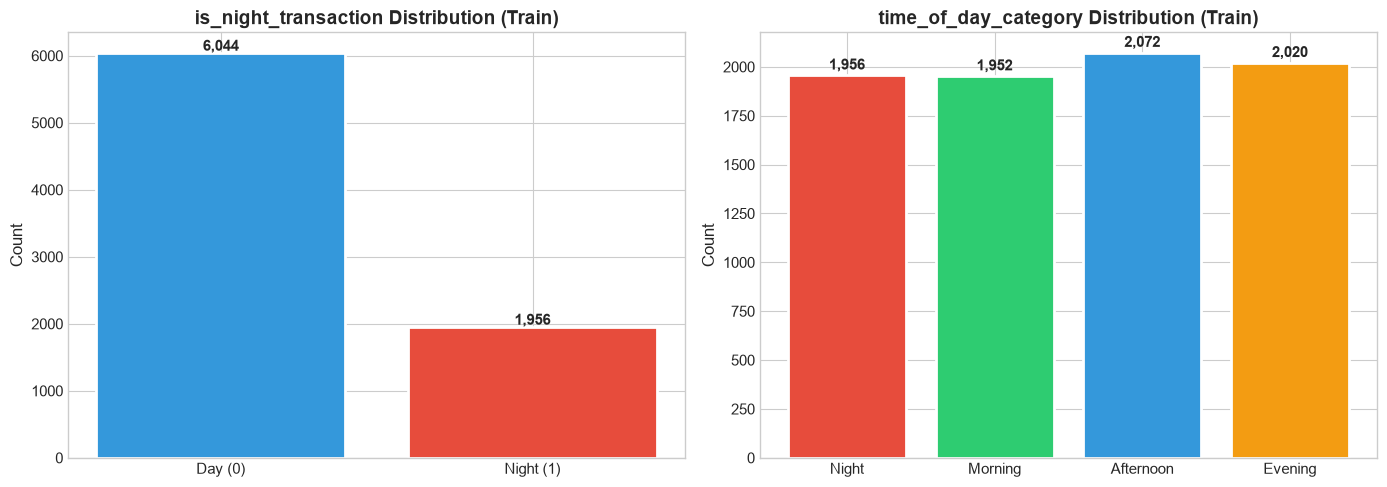

✅ Time-based features created: is_night_transaction, time_of_day_category


In [12]:
# Feature 1: is_night_transaction (binary flag for hours 0-5)
combined['is_night_transaction'] = combined['transaction_hour'].apply(
    lambda x: 1 if 0 <= x <= 5 else 0
)

# Feature 2: time_of_day_category (broader temporal binning)
def get_time_category(hour):
    if 0 <= hour <= 5:
        return 'Night'
    elif 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 17:
        return 'Afternoon'
    else:
        return 'Evening'

combined['time_of_day_category'] = combined['transaction_hour'].apply(get_time_category)

# Verify distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# is_night_transaction distribution
night_counts = combined.iloc[:n_train]['is_night_transaction'].value_counts().sort_index()
axes[0].bar(['Day (0)', 'Night (1)'], night_counts.values,
            color=[FEATURE_COLOR, '#e74c3c'], edgecolor='white', linewidth=2)
axes[0].set_title('is_night_transaction Distribution (Train)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(night_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# time_of_day_category distribution
tod_counts = combined.iloc[:n_train]['time_of_day_category'].value_counts()
tod_order = ['Night', 'Morning', 'Afternoon', 'Evening']
tod_counts = tod_counts.reindex(tod_order)
tod_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
axes[1].bar(tod_counts.index, tod_counts.values,
            color=tod_colors, edgecolor='white', linewidth=2)
axes[1].set_title('time_of_day_category Distribution (Train)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(tod_counts.values):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('✅ Time-based features created: is_night_transaction, time_of_day_category')

### 5.2 Trust & Anomaly Ratio Features

These continuous features capture **interactions** between raw features that are individually predictive of fraud:
- **`amount_to_trust_ratio`**: Fraudsters often attempt high-value transactions on low-trust devices.
- **`amount_velocity_ratio`**: High spend-per-recent-transaction indicates potential account takeover.

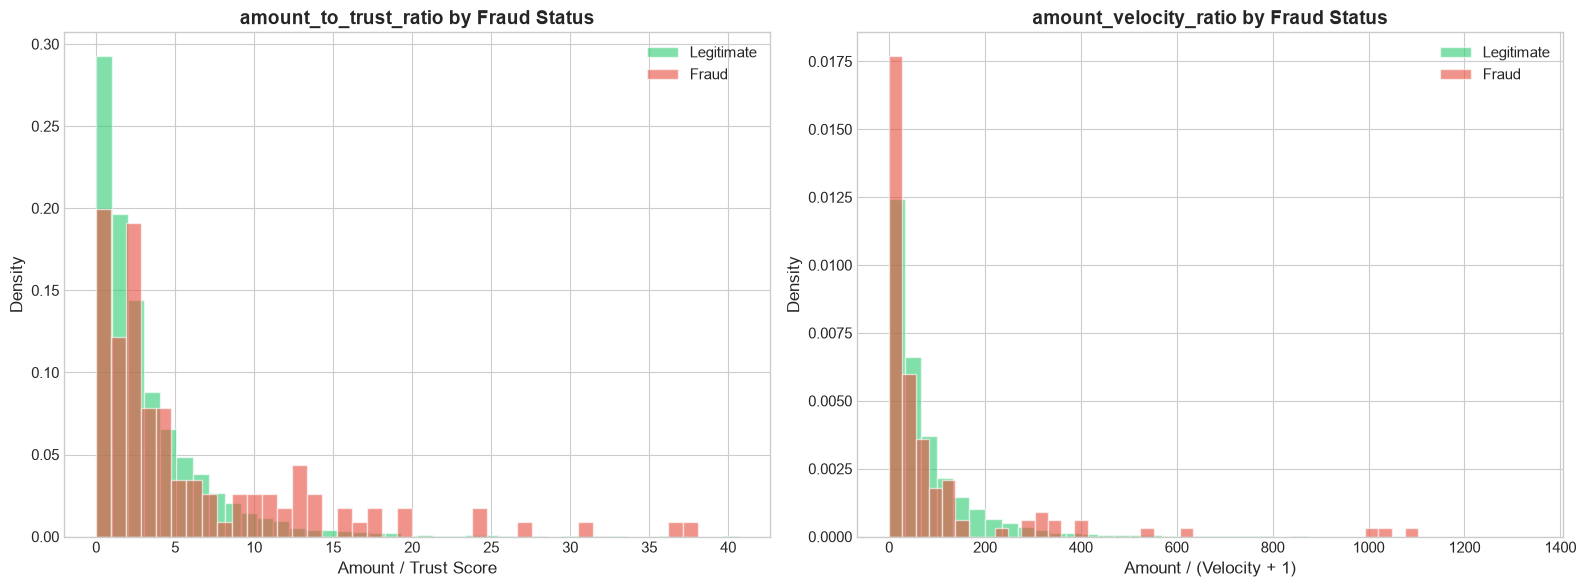

Ratio Feature Statistics (Train):
  amount_to_trust_ratio — mean: 3.25, std: 3.72
  amount_velocity_ratio — mean: 75.81, std: 96.20

✅ Trust/anomaly ratio features created: amount_to_trust_ratio, amount_velocity_ratio


In [13]:
# Feature 3: amount_to_trust_ratio
# Small epsilon to prevent division by zero (trust_score min is 25, so safe anyway)
combined['amount_to_trust_ratio'] = combined['amount'] / (combined['device_trust_score'] + 1e-6)

# Feature 4: amount_velocity_ratio
# +1 to avoid division by zero (velocity can be 0)
combined['amount_velocity_ratio'] = combined['amount'] / (combined['velocity_last_24h'] + 1)

# Visualize these new features by fraud status
train_with_target = combined.iloc[:n_train].copy()
train_with_target['is_fraud'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# amount_to_trust_ratio by fraud status
legit = train_with_target[train_with_target['is_fraud'] == 0]['amount_to_trust_ratio']
fraud = train_with_target[train_with_target['is_fraud'] == 1]['amount_to_trust_ratio']
axes[0].hist(legit, bins=40, density=True, alpha=0.6, color='#2ecc71',
             edgecolor='white', label='Legitimate')
axes[0].hist(fraud, bins=40, density=True, alpha=0.6, color='#e74c3c',
             edgecolor='white', label='Fraud')
axes[0].set_title('amount_to_trust_ratio by Fraud Status', fontweight='bold')
axes[0].set_xlabel('Amount / Trust Score')
axes[0].set_ylabel('Density')
axes[0].legend()

# amount_velocity_ratio by fraud status
legit_vel = train_with_target[train_with_target['is_fraud'] == 0]['amount_velocity_ratio']
fraud_vel = train_with_target[train_with_target['is_fraud'] == 1]['amount_velocity_ratio']
axes[1].hist(legit_vel, bins=40, density=True, alpha=0.6, color='#2ecc71',
             edgecolor='white', label='Legitimate')
axes[1].hist(fraud_vel, bins=40, density=True, alpha=0.6, color='#e74c3c',
             edgecolor='white', label='Fraud')
axes[1].set_title('amount_velocity_ratio by Fraud Status', fontweight='bold')
axes[1].set_xlabel('Amount / (Velocity + 1)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Ratio Feature Statistics (Train):')
print(f"  amount_to_trust_ratio — mean: {combined.iloc[:n_train]['amount_to_trust_ratio'].mean():.2f}, "
      f"std: {combined.iloc[:n_train]['amount_to_trust_ratio'].std():.2f}")
print(f"  amount_velocity_ratio — mean: {combined.iloc[:n_train]['amount_velocity_ratio'].mean():.2f}, "
      f"std: {combined.iloc[:n_train]['amount_velocity_ratio'].std():.2f}")
print()
print('✅ Trust/anomaly ratio features created: amount_to_trust_ratio, amount_velocity_ratio')

### 5.3 High-Risk Location Features

From EDA, `foreign_transaction` (5.4× uplift) and `location_mismatch` (5.5× uplift) are the **two strongest individual fraud signals**. We create composite features to capture their interaction:
- **`is_high_risk_location`**: Either flag is set → high risk.
- **`location_anomaly_score`**: Sum of both flags (0, 1, or 2) → severity of location anomaly.

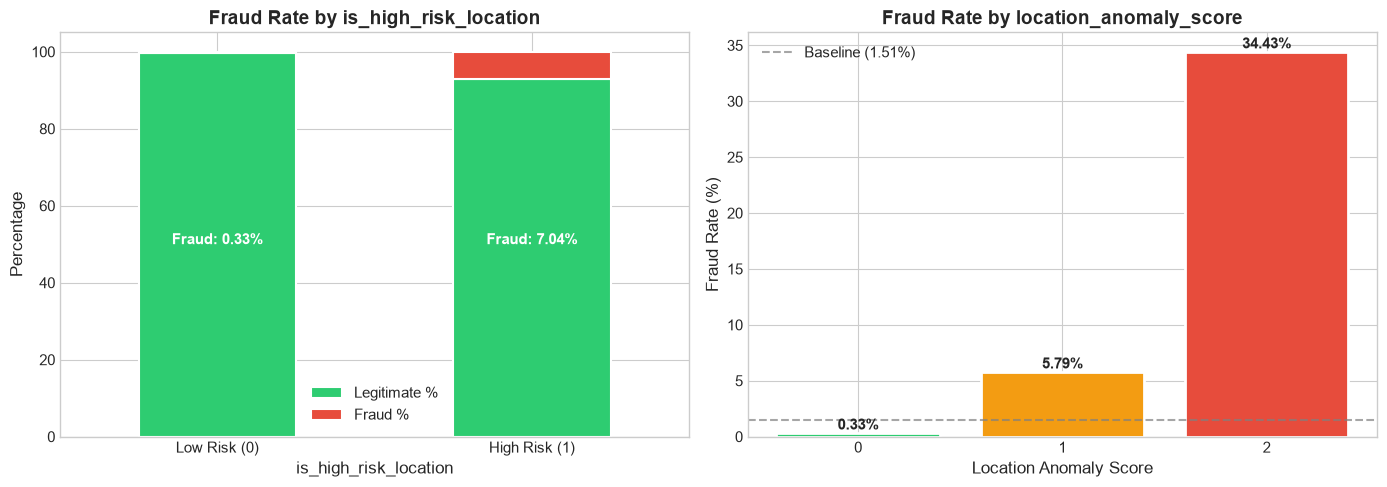

🔍 Key Insight: When BOTH foreign_transaction=1 AND location_mismatch=1 (score=2),
   the fraud rate is dramatically higher than the baseline.

✅ Location risk features created: is_high_risk_location, location_anomaly_score


In [14]:
# Feature 5: is_high_risk_location (OR of both location flags)
combined['is_high_risk_location'] = (
    (combined['foreign_transaction'] == 1) | (combined['location_mismatch'] == 1)
).astype(int)

# Feature 6: location_anomaly_score (additive: 0, 1, or 2)
combined['location_anomaly_score'] = (
    combined['foreign_transaction'] + combined['location_mismatch']
)

# Visualize the interaction
train_with_target = combined.iloc[:n_train].copy()
train_with_target['is_fraud'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# is_high_risk_location by fraud
ct1 = pd.crosstab(train_with_target['is_high_risk_location'],
                   train_with_target['is_fraud'], normalize='index') * 100
ct1.columns = ['Legitimate %', 'Fraud %']
ct1.plot(kind='bar', stacked=True, ax=axes[0], color=FRAUD_PALETTE,
         edgecolor='white', linewidth=1.5)
axes[0].set_title('Fraud Rate by is_high_risk_location', fontweight='bold')
axes[0].set_xticklabels(['Low Risk (0)', 'High Risk (1)'], rotation=0)
axes[0].set_ylabel('Percentage')
for j, (idx, row) in enumerate(ct1.iterrows()):
    axes[0].text(j, 50, f"Fraud: {row['Fraud %']:.2f}%",
                ha='center', fontweight='bold', fontsize=11, color='white')

# location_anomaly_score by fraud
fraud_by_score = train_with_target.groupby('location_anomaly_score')['is_fraud'].mean() * 100
score_colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(fraud_by_score.index.astype(str), fraud_by_score.values,
            color=score_colors[:len(fraud_by_score)], edgecolor='white', linewidth=2)
axes[1].set_title('Fraud Rate by location_anomaly_score', fontweight='bold')
axes[1].set_xlabel('Location Anomaly Score')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=1.51, color='gray', linestyle='--', alpha=0.7, label='Baseline (1.51%)')
axes[1].legend()
for j, (idx, val) in enumerate(fraud_by_score.items()):
    axes[1].text(j, val + 0.3, f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('🔍 Key Insight: When BOTH foreign_transaction=1 AND location_mismatch=1 (score=2),')
print('   the fraud rate is dramatically higher than the baseline.')
print()
print('✅ Location risk features created: is_high_risk_location, location_anomaly_score')

### 5.4 Strategic Binning Features

We create binary threshold features for key continuous variables based on EDA-identified breakpoints:
- **`is_high_amount`**: Transactions > $500 have a 3.04% fraud rate (2× baseline).
- **`is_low_trust`**: Trust score < 40 has a ~6% fraud rate (4× baseline).

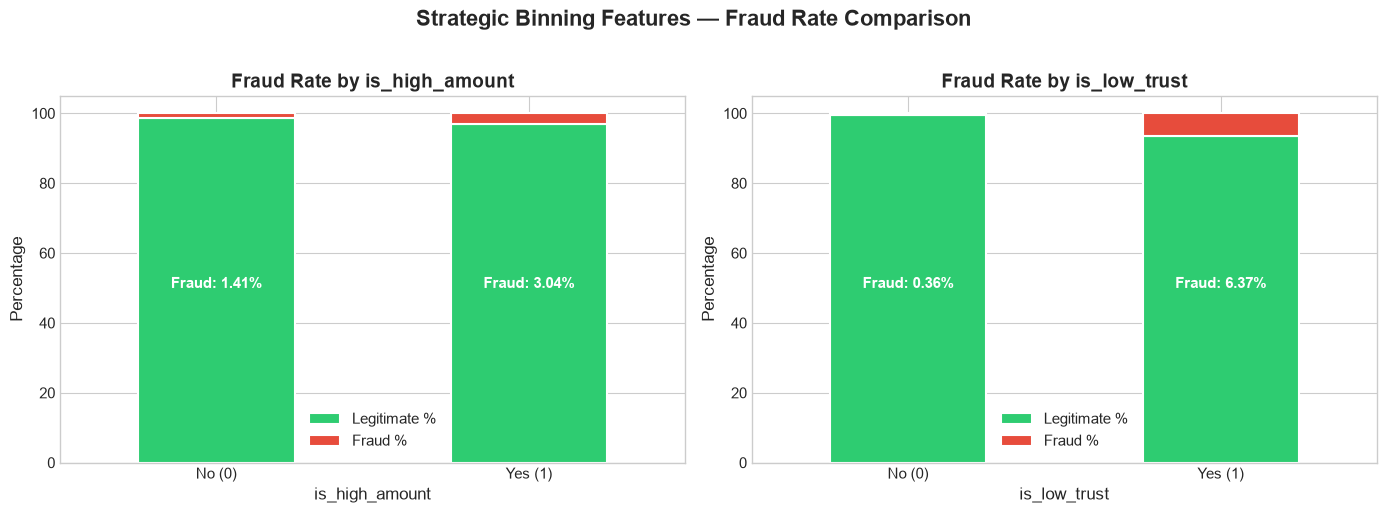

✅ Strategic binning features created: is_high_amount, is_low_trust


In [15]:
# Feature 7: is_high_amount (amount > 500)
combined['is_high_amount'] = (combined['amount'] > 500).astype(int)

# Feature 8: is_low_trust (device_trust_score < 40)
combined['is_low_trust'] = (combined['device_trust_score'] < 40).astype(int)

# Visualize
train_with_target = combined.iloc[:n_train].copy()
train_with_target['is_fraud'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['is_high_amount', 'is_low_trust']):
    ct = pd.crosstab(train_with_target[col],
                     train_with_target['is_fraud'], normalize='index') * 100
    ct.columns = ['Legitimate %', 'Fraud %']
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=FRAUD_PALETTE,
            edgecolor='white', linewidth=1.5)
    axes[i].set_title(f'Fraud Rate by {col}', fontweight='bold')
    axes[i].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
    axes[i].set_ylabel('Percentage')
    for j, (idx, row) in enumerate(ct.iterrows()):
        axes[i].text(j, 50, f"Fraud: {row['Fraud %']:.2f}%",
                    ha='center', fontweight='bold', fontsize=11, color='white')

plt.suptitle('Strategic Binning Features — Fraud Rate Comparison',
             fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print('✅ Strategic binning features created: is_high_amount, is_low_trust')

---

## 6. Categorical Encoding

### 6.1 One-Hot Encoding

We apply **One-Hot Encoding** to the categorical columns:
- `merchant_category` — 5 unique values: Food, Clothing, Travel, Electronics, Grocery
- `time_of_day_category` — 4 unique values: Night, Morning, Afternoon, Evening

**Why One-Hot Encoding?**
- Only 5 + 4 = 9 new columns — minimal dimensionality increase.
- No ordinal relationship exists between categories.
- Works well with both tree-based and linear models.
- We use `drop_first=False` to preserve all information for tree-based models.

In [16]:
# Columns to encode
cat_cols = ['merchant_category', 'time_of_day_category']

print('Before encoding:')
for col in cat_cols:
    print(f'  {col}: {combined[col].nunique()} unique values — {combined[col].unique().tolist()}')
print(f'  Total columns: {combined.shape[1]}')
print()

# Apply One-Hot Encoding
combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=False)

# Convert any boolean columns to integers (pd.get_dummies may produce bool dtypes)
for col in combined_encoded.columns:
    if combined_encoded[col].dtype == 'bool':
        combined_encoded[col] = combined_encoded[col].astype(int)

print('After encoding:')
print(f'  Total columns: {combined_encoded.shape[1]}')
print(f'  New columns added: {combined_encoded.shape[1] - combined.shape[1] + len(cat_cols)}')
print()

# Show the new encoded column names
new_cols = [c for c in combined_encoded.columns if c not in combined.columns]
print('Encoded columns:')
for c in new_cols:
    print(f'  • {c}')

print()
print('✅ One-Hot Encoding applied successfully.')

Before encoding:
  merchant_category: 5 unique values — ['Food', 'Electronics', 'Grocery', 'Clothing', 'Travel']
  time_of_day_category: 4 unique values — ['Morning', 'Night', 'Evening', 'Afternoon']
  Total columns: 16

After encoding:
  Total columns: 23
  New columns added: 9

Encoded columns:
  • merchant_category_Clothing
  • merchant_category_Electronics
  • merchant_category_Food
  • merchant_category_Grocery
  • merchant_category_Travel
  • time_of_day_category_Afternoon
  • time_of_day_category_Evening
  • time_of_day_category_Morning
  • time_of_day_category_Night

✅ One-Hot Encoding applied successfully.


---

## 7. Feature Scaling Discussion

Feature scaling is **model-dependent**:

| Model Type | Scaling Needed? | Reason |
|---|---|---|
| Random Forest, XGBoost, LightGBM, CatBoost | ❌ No | Tree-based models split on feature values — scale invariant |
| Logistic Regression, SVM, Neural Networks | ✅ Yes | Distance/gradient-based models are scale-sensitive |

**Decision:** We **do not apply scaling** in this preprocessing step because:
1. Our primary models will be tree-based (XGBoost, LightGBM, Random Forest).
2. If we later add a Logistic Regression baseline, we'll apply `StandardScaler` in the model pipeline (not in the data itself).
3. Keeping raw feature values preserves interpretability and allows tree-based models to access natural distributions.

**Features that would need scaling if used with linear models:**
- `amount` (range: 0 – 1,471)
- `device_trust_score` (range: 25 – 99)
- `velocity_last_24h` (range: 0 – 9)
- `cardholder_age` (range: 18 – 69)
- `transaction_hour` (range: 0 – 23)
- `amount_to_trust_ratio` (continuous, wide range)
- `amount_velocity_ratio` (continuous, wide range)

In [17]:
# Document feature ranges for reference
print('Feature Ranges (Combined Dataset):')
print('=' * 60)
for col in combined_encoded.select_dtypes(include=[np.number]).columns:
    col_min = combined_encoded[col].min()
    col_max = combined_encoded[col].max()
    col_mean = combined_encoded[col].mean()
    col_std = combined_encoded[col].std()
    print(f'{col:<30} range: [{col_min:>8.2f}, {col_max:>8.2f}]  '
          f'mean: {col_mean:>8.2f}  std: {col_std:>8.2f}')

print()
print('ℹ️  Scaling will be applied within model pipelines if needed (not here).')

Feature Ranges (Combined Dataset):
amount                         range: [    0.00,  1471.04]  mean:   175.95  std:   175.39
transaction_hour               range: [    0.00,    23.00]  mean:    11.59  std:     6.92
foreign_transaction            range: [    0.00,     1.00]  mean:     0.10  std:     0.30
location_mismatch              range: [    0.00,     1.00]  mean:     0.09  std:     0.28
device_trust_score             range: [   25.00,    99.00]  mean:    61.80  std:    21.49
velocity_last_24h              range: [    0.00,     9.00]  mean:     2.01  std:     1.43
cardholder_age                 range: [   18.00,    69.00]  mean:    43.47  std:    14.98
is_night_transaction           range: [    0.00,     1.00]  mean:     0.25  std:     0.43
amount_to_trust_ratio          range: [    0.00,    41.47]  mean:     3.28  std:     3.74
amount_velocity_ratio          range: [    0.00,  1354.54]  mean:    75.95  std:    97.39
is_high_risk_location          range: [    0.00,     1.00]  mean:

---

## 8. Split & Save Processed Data

### 8.1 Split Combined Dataset Back to Train/Test

In [18]:
# Split back into train and test
train_engineered = combined_encoded.iloc[:n_train].copy()
test_engineered = combined_encoded.iloc[n_train:].copy()

# Add target back to training set
train_engineered['is_fraud'] = y_train.values

print(f'Engineered Train: {train_engineered.shape[0]:,} rows × {train_engineered.shape[1]} columns')
print(f'Engineered Test:  {test_engineered.shape[0]:,} rows × {test_engineered.shape[1]} columns')
print()

# Sanity checks
assert train_engineered.isnull().sum().sum() == 0, 'Null values found in train!'
assert test_engineered.isnull().sum().sum() == 0, 'Null values found in test!'
assert 'is_fraud' in train_engineered.columns, 'is_fraud missing from train!'
assert 'is_fraud' not in test_engineered.columns, 'is_fraud found in test!'
assert len(train_engineered) == n_train, 'Train row count mismatch!'
assert len(test_engineered) + n_train == len(combined_encoded), 'Test row count mismatch!'

print('✅ All sanity checks passed.')

Engineered Train: 8,000 rows × 24 columns
Engineered Test:  2,000 rows × 23 columns

✅ All sanity checks passed.


### 8.2 Save to Disk

In [19]:
# Ensure output directory exists
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

# Save engineered datasets
train_path = os.path.join(output_dir, 'train_engineered.csv')
test_path = os.path.join(output_dir, 'test_engineered.csv')
ids_path = os.path.join(output_dir, 'test_transaction_ids.csv')

train_engineered.to_csv(train_path, index=False)
test_engineered.to_csv(test_path, index=False)
test_ids.to_csv(ids_path, index=False, header=['transaction_id'])

print('Saved files:')
print(f'  📄 {train_path}')
print(f'     → {train_engineered.shape[0]:,} rows × {train_engineered.shape[1]} columns')
print(f'     → Size: {os.path.getsize(train_path) / 1024:.1f} KB')
print()
print(f'  📄 {test_path}')
print(f'     → {test_engineered.shape[0]:,} rows × {test_engineered.shape[1]} columns')
print(f'     → Size: {os.path.getsize(test_path) / 1024:.1f} KB')
print()
print(f'  📄 {ids_path}')
print(f'     → {len(test_ids):,} transaction IDs')
print(f'     → Size: {os.path.getsize(ids_path) / 1024:.1f} KB')
print()
print('✅ All processed files saved successfully.')

Saved files:
  📄 ../data/processed\train_engineered.csv
     → 8,000 rows × 24 columns
     → Size: 629.5 KB

  📄 ../data/processed\test_engineered.csv
     → 2,000 rows × 23 columns
     → Size: 154.0 KB

  📄 ../data/processed\test_transaction_ids.csv
     → 2,000 transaction IDs
     → Size: 11.5 KB

✅ All processed files saved successfully.


---

## 9. Final Feature Matrix Overview

A comprehensive view of the final engineered feature matrix.

In [20]:
# Feature summary table
feature_info = []
for col in train_engineered.columns:
    dtype = str(train_engineered[col].dtype)
    nunique = train_engineered[col].nunique()
    is_original = col in ['amount', 'transaction_hour', 'foreign_transaction',
                          'location_mismatch', 'device_trust_score',
                          'velocity_last_24h', 'cardholder_age', 'is_fraud']
    source = 'Original' if is_original else 'Engineered'
    feature_info.append({
        'Feature': col,
        'Dtype': dtype,
        'Unique': nunique,
        'Source': source
    })

feature_df = pd.DataFrame(feature_info)
print('Final Feature Matrix Summary:')
print('=' * 65)
print(feature_df.to_string(index=False))
print()
print(f'Total features (including target): {len(feature_df)}')
print(f'  Original features: {(feature_df["Source"] == "Original").sum()}')
print(f'  Engineered features: {(feature_df["Source"] == "Engineered").sum()}')

Final Feature Matrix Summary:
                       Feature   Dtype  Unique     Source
                        amount float64    7216   Original
              transaction_hour   int64      24   Original
           foreign_transaction   int64       2   Original
             location_mismatch   int64       2   Original
            device_trust_score   int64      75   Original
             velocity_last_24h   int64      10   Original
                cardholder_age   int64      52   Original
          is_night_transaction   int64       2 Engineered
         amount_to_trust_ratio float64    7991 Engineered
         amount_velocity_ratio float64    7607 Engineered
         is_high_risk_location   int64       2 Engineered
        location_anomaly_score   int64       3 Engineered
                is_high_amount   int64       2 Engineered
                  is_low_trust   int64       2 Engineered
    merchant_category_Clothing   int64       2 Engineered
 merchant_category_Electronics   int64    

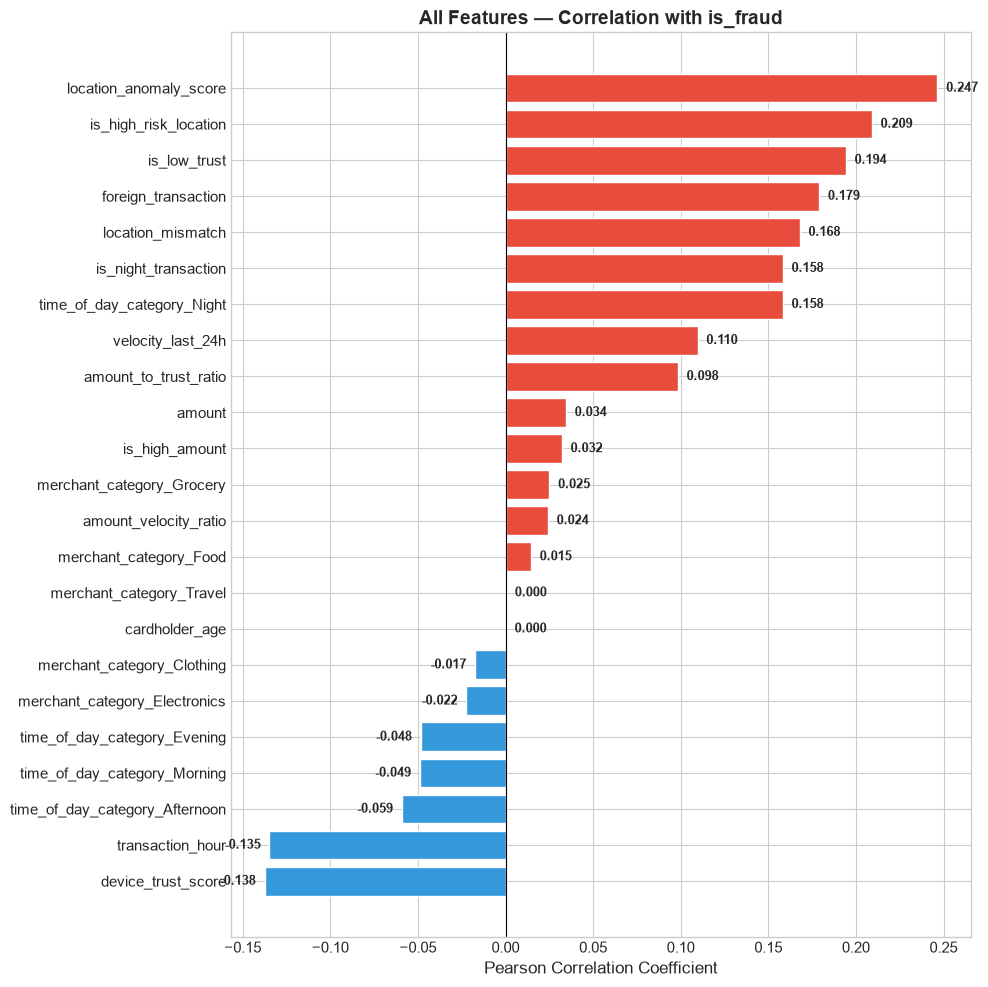


Top 5 fraud signals (by absolute correlation):
  1. location_anomaly_score         +0.247
  2. is_high_risk_location          +0.209
  3. is_low_trust                   +0.194
  4. foreign_transaction            +0.179
  5. location_mismatch              +0.168


In [21]:
# Correlation of all features with target
target_corr = train_engineered.corr()['is_fraud'].drop('is_fraud').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors,
               edgecolor='white', linewidth=1)
ax.set_title('All Features — Correlation with is_fraud', fontweight='bold', fontsize=14)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)

for bar, val in zip(bars, target_corr.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2.,
            f'{val:.3f}', va='center', ha=ha, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 5 fraud signals (by absolute correlation):')
top_corr = target_corr.abs().sort_values(ascending=False).head(5)
for i, (feat, corr) in enumerate(top_corr.items(), 1):
    actual_corr = target_corr[feat]
    direction = '+' if actual_corr > 0 else ''
    print(f'  {i}. {feat:<30} {direction}{actual_corr:.3f}')

---

## 10. Summary

### Data Cleaning
| Step | Action | Result |
|---|---|---|
| Missing values | Verified none exist | ✅ Clean |
| Duplicates | Verified none exist | ✅ Clean |
| Data types | Verified consistency | ✅ Consistent |
| Binary columns | Verified {0,1} values | ✅ Valid |
| Outliers | Kept (signal, not noise) | ✅ Preserved |
| `transaction_id` | Dropped from features | ✅ Saved separately |

### Feature Engineering
| Feature | Type | Motivation |
|---|---|---|
| `is_night_transaction` | Binary | Night hours have 3.3× fraud uplift |
| `time_of_day_category` | One-Hot (4 cols) | Broader temporal patterns |
| `amount_to_trust_ratio` | Continuous | High amount + low trust = suspicious |
| `amount_velocity_ratio` | Continuous | Spend per recent transaction |
| `is_high_risk_location` | Binary | Location-based risk flag |
| `location_anomaly_score` | Integer (0–2) | Combined location risk severity |
| `is_high_amount` | Binary | Amount >$500 → 2× fraud rate |
| `is_low_trust` | Binary | Trust <40 → 4× fraud rate |
| `merchant_category` | One-Hot (5 cols) | Categorical encoding |

### Output Files
- `data/processed/train_engineered.csv` — 24 columns (23 features + target)
- `data/processed/test_engineered.csv` — 23 columns (features only)
- `data/processed/test_transaction_ids.csv` — Preserved for submission

### Key Decisions
1. **No outlier removal** — Outliers are fraud signals in this domain.
2. **No feature scaling** — Primary models are tree-based (scale invariant). Scaling will be applied in model pipelines if needed.
3. **Raw features preserved** — Originals kept alongside engineered features for tree-based models to access natural distributions.
4. **One-Hot Encoding without drop_first** — Preserves all information; works best with tree models.

**→ Next: `03_Model_Training.ipynb` — Model development, comparison, and selection.**